In [2]:
%load_ext autoreload
%autoreload 2

import util.plotting_helpers as plothelp
import matplotlib.pyplot as plt
import earthaccess
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Transformer
from scipy import interpolate



auth = earthaccess.login(strategy="netrc")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def get_swot_granule_data(granule_type):
    """
    Prompts the user for SWOT granule details and returns the opened xarray Dataset.
    """
    print(f"\n--- Enter {granule_type} SWOT granule details ---")
    results = earthaccess.search_data(
        short_name="SWOT_L2_HR_Raster_D",
        granule_name=input(f"Granule name for {granule_type} (e.g., SWOT_L2_HR_Raster_250m_UTM54U_N_x_x_x_...): "),
        temporal=(
            input(f"Start date for {granule_type} (YYYY-MM-DD, e.g., 2025-06-02): "),
            input(f"End date for {granule_type} (YYYY-MM-DD, same as start for single day): ")
        ),
    )

    print(f"Number of granules found: {len(results)}")
    if len(results) == 0:
        print("No granules found! Check your search parameters.")
        return None
    else:
        print("Granules found. Proceeding to open...")
        return xr.open_dataset(earthaccess.open(results)[0], engine="h5netcdf")

In [4]:
def plot_swot_data(ax, ds, title, vmin, vmax):
    """
    Plots SWOT Water Surface Elevation data on a given axes.
    Returns the pcolormesh object and the sig0 data array.
    """
    if ds is None:
        ax.set_title(f"{title}\n(No data available)", fontsize=14)
        ax.set_visible(False) # Hide axis if no data
        return None, None

    # Get data
    sig0 = ds["sig0"]
    
    # Convert UTM to lat/lon
    utm_zone = ds.utm_zone_num
    utm_crs = ccrs.UTM(zone=utm_zone, southern_hemisphere=False)
    transformer = Transformer.from_crs(utm_crs, ccrs.PlateCarree(), always_xy=True)
    x_utm, y_utm = sig0["x"].values, sig0["y"].values
    X_utm, Y_utm = np.meshgrid(x_utm, y_utm)
    X_lon, Y_lat = transformer.transform(X_utm, Y_utm)
    
    # Plot data
    mesh = ax.pcolormesh(
        X_lon,
        Y_lat,
        sig0.values,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    
    # Add map features
    ax.gridlines(draw_labels=True)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.coastlines(resolution='10m', linewidth=1)
    ax.set_title(title, fontsize=14)
    
    return mesh, sig0


In [5]:
def plot_difference(ax, ds_before, ds_after, title, vmin, vmax):
    """
    Calculates and plots the difference between two SWOT sig0 datasets.
    Returns the pcolormesh object.
    """
    if ds_before is None or ds_after is None:
        ax.set_title(f"{title}\n(Cannot compute difference due to missing data)", fontsize=14)
        ax.set_visible(False) # Hide axis if no data
        return None

    sig0_before = ds_before["sig0"] + ds_before["height_cor_xover"]
    sig0_after = ds_after["sig0"] + ds_after["height_cor_xover"]

    # Handle differing UTM zones - reproject 'before' onto 'after's grid for difference calculation
    # For a robust solution, you might want to reproject both to a common CRS if they are very different.
    if ds_before.utm_zone_num != ds_after.utm_zone_num:
        print(f"Warning: UTM zones differ (Before: {ds_before.utm_zone_num}, After: {ds_after.utm_zone_num}). Reprojecting 'before' to 'after's CRS for difference calculation.")
        # Create transformers for both datasets
        transformer_before_to_latlon = Transformer.from_crs(
            ccrs.UTM(zone=ds_before.utm_zone_num, southern_hemisphere=False),
            ccrs.PlateCarree(),
            always_xy=True
        )
        transformer_after_to_latlon = Transformer.from_crs(
            ccrs.UTM(zone=ds_after.utm_zone_num, southern_hemisphere=False),
            ccrs.PlateCarree(),
            always_xy=True
        )

        # Get lat/lon for both datasets
        x_before_utm, y_before_utm = sig0_before["x"].values, sig0_before["y"].values
        X_before_utm, Y_before_utm = np.meshgrid(x_before_utm, y_before_utm)
        lon_before, lat_before = transformer_before_to_latlon.transform(X_before_utm, Y_before_utm)

        x_after_utm, y_after_utm = sig0_after["x"].values, sig0_after["y"].values
        X_after_utm, Y_after_utm = np.meshgrid(x_after_utm, y_after_utm)
        lon_after, lat_after = transformer_after_to_latlon.transform(X_after_utm, Y_after_utm)

        # Create xarray DataArrays with lat/lon coordinates for interpolation
        sig0_before_ll = xr.DataArray(
            sig0_before.values,
            coords={'lat': lat_before[:,0], 'lon': lon_before[0,:]}, # Assuming rectilinear grid
            dims=['y', 'x']
        ).rename({'y': 'lat', 'x': 'lon'})

        sig0_after_ll = xr.DataArray(
            sig0_after.values,
            coords={'lat': lat_after[:,0], 'lon': lon_after[0,:]},
            dims=['y', 'x']
        ).rename({'y': 'lat', 'x': 'lon'})

        # Interpolate 'before' onto 'after's lat/lon grid
        try:
            sig0_before_interpolated = sig0_before_ll.interp(lat=sig0_after_ll.lat, lon=sig0_after_ll.lon, method="linear")
            sig0_diff = sig0_after_ll - sig0_before_interpolated
        except Exception as e:
            print(f"Error during interpolation for difference: {e}. Cannot compute difference with differing UTM zones.")
            ax.set_title(f"{title}\n(Error in re-gridding)", fontsize=14)
            ax.set_visible(False)
            return None
        
        # Use the 'after' grid for plotting the difference
        X_lon, Y_lat = lon_after, lat_after
        utm_crs_plot = ccrs.UTM(zone=ds_after.utm_zone_num, southern_hemisphere=False) # Use after's zone for plotting CRS
    else:
        # If UTM zones are the same, proceed with direct difference on original grid if aligned,
        # or interpolate if necessary (e.g., if coordinates are slightly off)
        try:
            # Attempt to interpolate before onto after's grid for precise alignment
            sig0_before_aligned = sig0_before.interp(x=sig0_after.x, y=sig0_after.y, method="linear")
            sig0_diff = sig0_after - sig0_before_aligned
        except Exception as e:
            print(f"Error interpolating sig0 'before' onto 'after' grid: {e}. Proceeding with direct subtraction (assuming perfect grid alignment).")
            # Fallback to direct subtraction if interpolation fails, assuming similar grids
            if sig0_before.shape == sig0_after.shape and np.allclose(sig0_before['x'], sig0_after['x']) and np.allclose(sig0_before['y'], sig0_after['y']):
                sig0_diff = sig0_after - sig0_before
            else:
                print("Direct difference not possible due to incompatible grids. Skipping difference plot.")
                ax.set_title(f"{title}\n(Incompatible data grids)", fontsize=14)
                ax.set_visible(False)
                return None
        
        utm_crs_plot = ccrs.UTM(zone=ds_before.utm_zone_num, southern_hemisphere=False) # Use either zone
        transformer = Transformer.from_crs(utm_crs_plot, ccrs.PlateCarree(), always_xy=True)
        x_utm, y_utm = sig0_after["x"].values, sig0_after["y"].values # Use after's grid for plotting
        X_utm, Y_utm = np.meshgrid(x_utm, y_utm)
        X_lon, Y_lat = transformer.transform(X_utm, Y_utm)

    mesh = ax.pcolormesh(
        X_lon,
        Y_lat,
        sig0_diff.values,
        transform=ccrs.PlateCarree(),
        cmap="RdBu", # Diverging colormap for differences
        vmin=vmin,
        vmax=vmax,
    )

    ax.gridlines(draw_labels=True)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.coastlines(resolution='10m', linewidth=1)
    ax.set_title(title, fontsize=14)

    return mesh

In [6]:
num_pairs = int(input("How many SWOT granule pairs (before and after) do you want to analyze? "))

swot_datasets = [] # To store tuples of (ds_before, ds_after)

for i in range(num_pairs):
    print(f"\n--- Collecting data for Pair {i+1} ---")
    ds_before = get_swot_granule_data("BEFORE")
    ds_after = get_swot_granule_data("AFTER")
    
    if ds_before is not None and ds_after is not None:
        swot_datasets.append((ds_before, ds_after))
    elif ds_before is None and ds_after is None:
        print(f"Skipping Pair {i+1} as no granules were found for both before and after.")
    elif ds_before is None:
        print(f"Skipping Pair {i+1} as no 'before' granule was found.")
    else: # ds_after is None
        print(f"Skipping Pair {i+1} as no 'after' granule was found.")

How many SWOT granule pairs (before and after) do you want to analyze?  1



--- Collecting data for Pair 1 ---

--- Enter BEFORE SWOT granule details ---


Granule name for BEFORE (e.g., SWOT_L2_HR_Raster_250m_UTM54U_N_x_x_x_...):  SWOT_L2_HR_Raster_250m_UTM32N_N_x_x_x_032_501_081F_20250515T220149_20250515T220151_PID0_01.nc
Start date for BEFORE (YYYY-MM-DD, e.g., 2025-06-02):  2025-05-15
End date for BEFORE (YYYY-MM-DD, same as start for single day):  2025-05-15


Number of granules found: 1
Granules found. Proceeding to open...


QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 583.68it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.60s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 12228.29it/s]



--- Enter AFTER SWOT granule details ---


Granule name for AFTER (e.g., SWOT_L2_HR_Raster_250m_UTM54U_N_x_x_x_...):  SWOT_L2_HR_Raster_250m_UTM32N_N_x_x_x_035_501_081F_20250717T121707_20250717T121708_PID0_01.nc
Start date for AFTER (YYYY-MM-DD, e.g., 2025-06-02):  2025-07-17
End date for AFTER (YYYY-MM-DD, same as start for single day):  2025-07-17


Number of granules found: 1
Granules found. Proceeding to open...


QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 1290.16it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:00<00:00,  8.23it/s]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 11397.57it/s]


Enter a main location title for all plots (e.g., 'Lower Mississippi River'):  Southeast coast of Nigeria



--- Plotting for Pair 1 ---


Title for Before Event (Pair 1) (e.g., Location, mm/dd/yyyy):  Coast of Akwa Ibom, 05/15/2025
Title for After Event (Pair 1) (e.g., Location, mm/dd/yyyy):  Coast of Akwa Ibom, 07/17/2025
Title for Difference Plot (Pair 1) (e.g., Change in sig0, mm/dd/yyyy):  Change in sig0


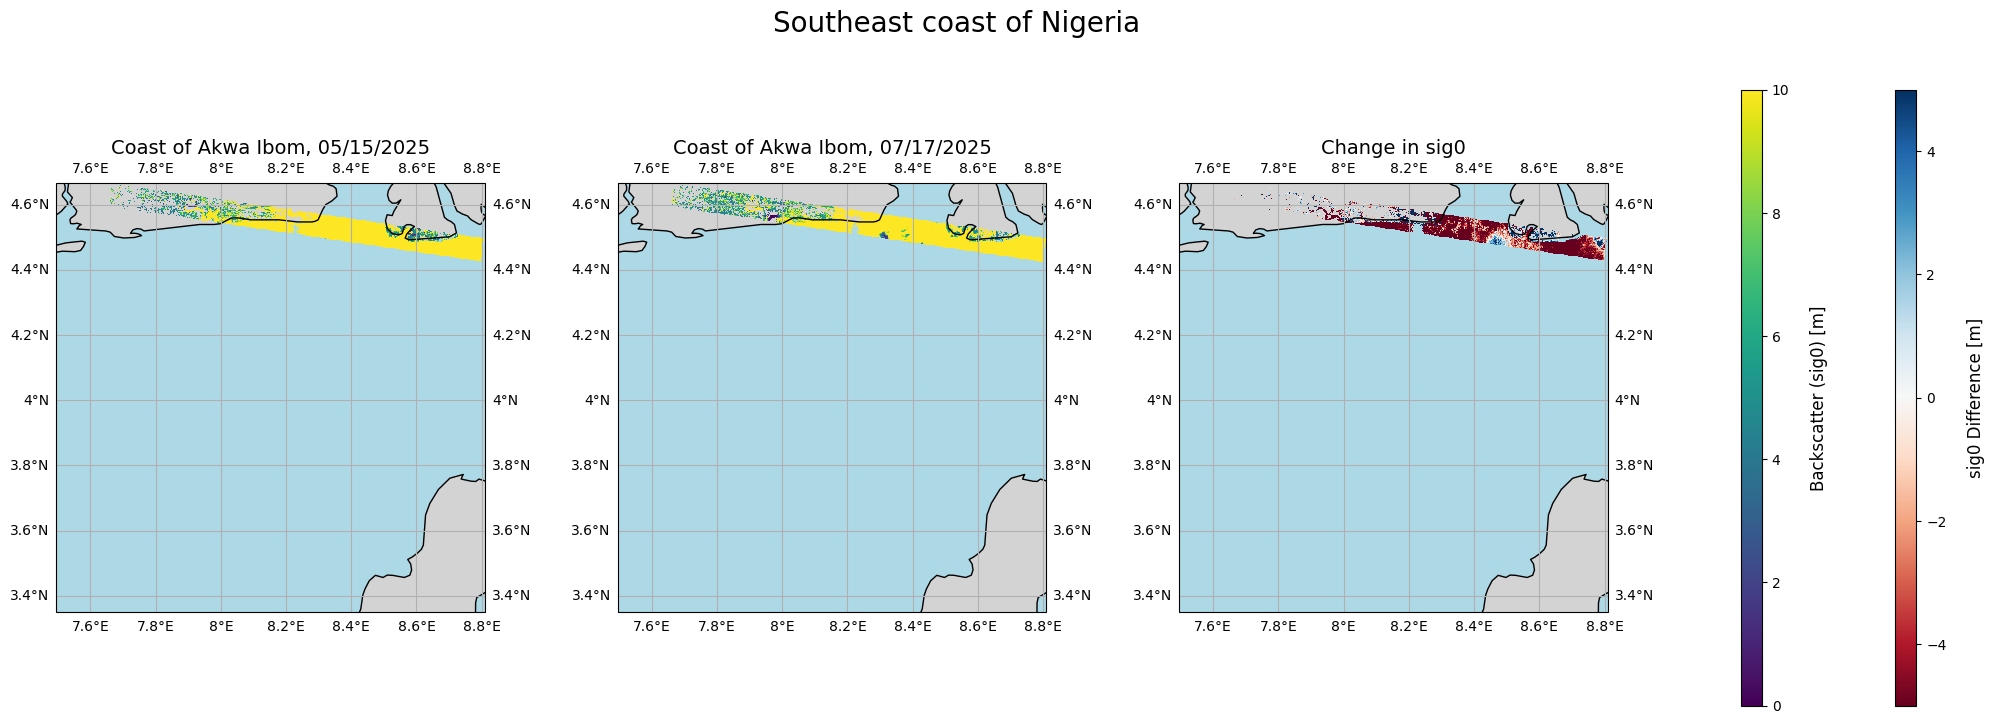

In [10]:
if not swot_datasets:
    print("No valid granule pairs were found or entered. Exiting.")
else:
    # Determine overall figure size and grid based on number of pairs
    # Each pair will have 3 plots (before, after, difference) + 2 colorbars (one for sig0, one for Difference)
    # We'll put colorbars to the right of their respective plots.
    num_rows = num_pairs
    num_cols = 3 # Before, After, Difference
    
    # Each row will have 3 main plots, plus two narrow columns for colorbars
    fig = plt.figure(figsize=(24, 8 * num_rows)) # Adjust figsize dynamically for better readability
    
    # Define grid spec. For each row: plot1, plot2, plot3, sig0_colorbar_space, diff_colorbar_space
    gs = fig.add_gridspec(num_rows, num_cols + 2, width_ratios=[1, 1, 1, 0.05, 0.05], wspace=0.5)
    
    main_location = input("Enter a main location title for all plots (e.g., 'Lower Mississippi River'): ")

    for i, (ds_before, ds_after) in enumerate(swot_datasets):
        print(f"\n--- Plotting for Pair {i+1} ---")
        # Determine plot titles based on user input for each pair
        title_before = input(f"Title for Before Event (Pair {i+1}) (e.g., Location, mm/dd/yyyy): ")
        title_after = input(f"Title for After Event (Pair {i+1}) (e.g., Location, mm/dd/yyyy): ")
        title_diff = input(f"Title for Difference Plot (Pair {i+1}) (e.g., Change in sig0, mm/dd/yyyy): ")

        # Before Plot
        ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
        mesh1, sig01 = plot_swot_data(ax1, ds_before, title_before, vmin=0, vmax=10) # Common sig0 range

        # After Plot
        ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
        mesh2, sig02 = plot_swot_data(ax2, ds_after, title_after, vmin=0, vmax=10) # Common sig0 range

        # Difference Plot
        ax3 = fig.add_subplot(gs[i, 2], projection=ccrs.PlateCarree())
        mesh3 = plot_difference(ax3, ds_before, ds_after, title_diff, vmin=-5, vmax=5) # Symmetric range for difference

        # sig0 Colorbar (for Before/After plots in this row)
        if mesh1: # Only add if the plot was successful
            cax_sig0 = fig.add_subplot(gs[i, num_cols]) # Position for sig0 colorbar
            cbar_sig0 = fig.colorbar(mesh1, cax=cax_sig0, orientation='vertical')
            cbar_sig0.set_label("Backscatter (sig0) [m]", fontsize=12, labelpad=15, rotation=90)
        
        # Difference Colorbar (for the Difference plot in this row)
        if mesh3: # Only add if the plot was successful
            cax_diff = fig.add_subplot(gs[i, num_cols + 1]) # Position for Difference colorbar
            cbar_diff = fig.colorbar(mesh3, cax=cax_diff, orientation='vertical')
            cbar_diff.set_label("sig0 Difference [m]", fontsize=12, labelpad=15, rotation=90)

    # Add the main title for the entire figure
    fig.text(
        x=0.5,
        y=0.98, # Adjust y position for the main title
        s=main_location,
        fontsize=20,
        color='black',
        va='top',
        ha='center'
    )

    #plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for the main title
    plt.show()